# 04 — Final Simplex-NMF Comparison

This notebook reproduces the final Moffett Field simplex-NMF comparison retained for the paper. The three methods are:

1. fixed-step single-row/column entropic row-action method;
2. fixed-step mini-batch-8 entropic row-action method;
3. deterministic simplex-constrained reference from the local `../nmfbook` repository.

The optimization problem is

$$
\min_{W,H} \; \frac12\|X-WH\|_F^2, \quad W\ge 0, \quad H_{:,j}\ge 0, \quad \mathbf{1}^T H_{:,j}=1.
$$

## 1. Imports and Reproducibility Settings

The standalone script is loaded by path because its public filename starts with `04_`. The notebook calls the same code used by the command-line experiment.

In [1]:
from __future__ import annotations

import importlib.util
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Markdown, display

SCRIPT_PATH = Path("../experiments/simplex_nmf_benchmark.py").resolve()
SPEC = importlib.util.spec_from_file_location("simplex_nmf_benchmark", SCRIPT_PATH)
comparison = importlib.util.module_from_spec(SPEC)
sys.modules[SPEC.name] = comparison
SPEC.loader.exec_module(comparison)

SEED = 123
N_OUTER = 200
OUTPUT_DIR = Path("../results/04_simplex_nmf_comparison")
FIGURE_DIR = Path("../figures/simplex_nmf_comparison")
np.random.seed(SEED)

def markdown_table(rows):
    if not rows:
        return ""
    columns = list(rows[0].keys())
    header = "| " + " | ".join(columns) + " |"
    separator = "|" + "|".join(["---"] * len(columns)) + "|"
    body = ["| " + " | ".join(str(row[column]) for column in columns) + " |" for row in rows]
    return "\n".join([header, separator, *body])

print(f"Loaded {SCRIPT_PATH}")

Matplotlib is building the font cache; this may take a moment.


Loaded /Users/valentinleplat/Documents/Python_Projects/randomized-row-action-framework/experiments/simplex_nmf_benchmark.py


## 2. Moffett Data Loading and Preprocessing

The script uses `load_moffett_mat` followed by `preprocess_hsi_global_scale`, matching the validated 50 x 50 crop, 159 retained spectral bands, orientation, and global scaling.

In [2]:
X, scale = comparison.load_problem(Path("../data/Moffet.mat"))
print("X shape:", X.shape)
print("Global scale:", scale)
assert X.shape == (159, 2500)

X shape: (159, 2500)
Global scale: 0.8


## 3. Common Initialization

We generate `W0` and `H0` once for seed 123 and pass exact copies to all methods. The single-row sampling RNG is advanced through the paper initialization draws, preserving the corrected ablation convention.

In [3]:
W0, H0 = comparison.initial_factors(X, rank=3, seed=SEED)
print("W0 shape:", W0.shape)
print("H0 shape:", H0.shape)
print("max simplex deviation in H0:", np.max(np.abs(H0.sum(axis=0) - 1.0)))

W0 shape: (159, 3)
H0 shape: (3, 2500)
max simplex deviation in H0: 3.3306690738754696e-16


## 4. Single-Row Update Formula

For each sampled spectral row `i`, the H update uses

$$
r_i = W_{i,:}H - X_{i,:}, \qquad
H \leftarrow \operatorname{normalize}_{\Delta}\left(H \odot \exp\left(-\eta_H \frac{W_{i,:}^T r_i}{\|W_{i,:}\|_2^2}\right)\right).
$$

For each sampled observation column `j`, the W update uses

$$
r_j = WH_{:,j} - X_{:,j}, \qquad
W \leftarrow \max\left(W \odot \exp\left(-\eta_W \frac{r_j H_{:,j}^T}{\|H_{:,j}\|_2^2}\right), 10^{-15}\right).
$$

Here `eta_H=0.1`, `eta_W=0.01`, with no warmup and no line search.

## 5. Mini-Batch-8 Derivation and Implementation

For an H block `I`,

$$
R_H = W[I,:]H - X[I,:], \quad G_H = W[I,:]^T R_H, \quad L_H = \|W[I,:]\|_2^2,
$$

$$
H \leftarrow \operatorname{normalize}_{\Delta}\left(H \odot \exp(-\eta_H G_H/L_H)\right).
$$

For a W block `J`,

$$
R_W = WH[:,J] - X[:,J], \quad G_W = R_W H[:,J]^T, \quad L_W = \|H[:,J]\|_2^2,
$$

$$
W \leftarrow \max(W \odot \exp(-\eta_W G_W/L_W), 10^{-15}).
$$

Sampling is without replacement inside each block and independent across block draws. The batch size is exactly 8.

## 6. Deterministic Reference Wrapper

The reference is imported from the local sibling repository `../nmfbook` using

```python
from algorithms.minvol_nmf.minvol_nmf import MinVolNMFOptions, minvol_nmf
```

The call uses model 4, `lam=0`, `maxiter=200`, and the same `W0/H0`.

In [4]:
MinVolNMFOptions, minvol_nmf, import_path = comparison.load_reference()
print("Reference import path:", import_path)
print("Reference function:", minvol_nmf)

Reference import path: algorithms.minvol_nmf.minvol_nmf:minvol_nmf
Reference function: <function minvol_nmf at 0x1149c9da0>


## 7. Execute the Three Methods

This cell reproduces the standalone script outputs and writes histories, factors, summaries, and figures.

In [5]:
config = comparison.ComparisonConfig(seed=SEED, n_outer=N_OUTER, data_path="../data/Moffet.mat")
rows = comparison.run_comparison(config, OUTPUT_DIR, FIGURE_DIR)
display(Markdown(markdown_table(rows)))

| method | display_name | objective | relative_error | runtime | simplex_violation | H_negativity | W_negativity |
|---|---|---|---|---|---|---|---|
| single_row_fixed | Single row | 34.81566292441049 | 0.04131308703525089 | 6.1269662079866976 | 2.220446049250313e-16 | 0.0 | 0.0 |
| minibatch8_fixed | Mini-batch 8 | 27.196131117432934 | 0.0365135346720663 | 2.651183041976765 | 2.220446049250313e-16 | 0.0 | 0.0 |
| reference | Deterministic reference | 21.583405628382025 | 0.032528220092207766 | 1.346412583021447 | 2.220446049250313e-16 | 0.0 | 0.0 |

## 8. Numerical Summary Table

In [6]:
import csv

summary_path = OUTPUT_DIR / "summary_seed123.csv"
with summary_path.open(newline="", encoding="utf-8") as handle:
    summary = list(csv.DictReader(handle))
display(Markdown(markdown_table(summary)))

| method | display_name | objective | relative_error | runtime | simplex_violation | H_negativity | W_negativity |
|---|---|---|---|---|---|---|---|
| single_row_fixed | Single row | 34.81566292441049 | 0.04131308703525089 | 6.1269662079866976 | 2.220446049250313e-16 | 0.0 | 0.0 |
| minibatch8_fixed | Mini-batch 8 | 27.196131117432934 | 0.0365135346720663 | 2.651183041976765 | 2.220446049250313e-16 | 0.0 | 0.0 |
| reference | Deterministic reference | 21.583405628382025 | 0.032528220092207766 | 1.346412583021447 | 2.220446049250313e-16 | 0.0 | 0.0 |

## 9. Automatic Component Alignment

Components are aligned to the reference by solving a 3 x 3 assignment problem that maximizes absolute spectral correlation between normalized W columns.

In [7]:
with open(OUTPUT_DIR / "component_alignment_seed123.json", "r", encoding="utf-8") as handle:
    print(handle.read())

{
  "component_labels": [
    "Water",
    "Vegetation",
    "Soil"
  ],
  "criterion": "maximize absolute spectral correlation with reference W columns",
  "note": "Physical material labels were validated after alignment to the reference ordering.",
  "permutations": {
    "minibatch8_fixed": [
      0,
      2,
      1
    ],
    "reference": [
      0,
      1,
      2
    ],
    "single_row_fixed": [
      1,
      0,
      2
    ]
  }
}



## 10. Abundance-Map Figure

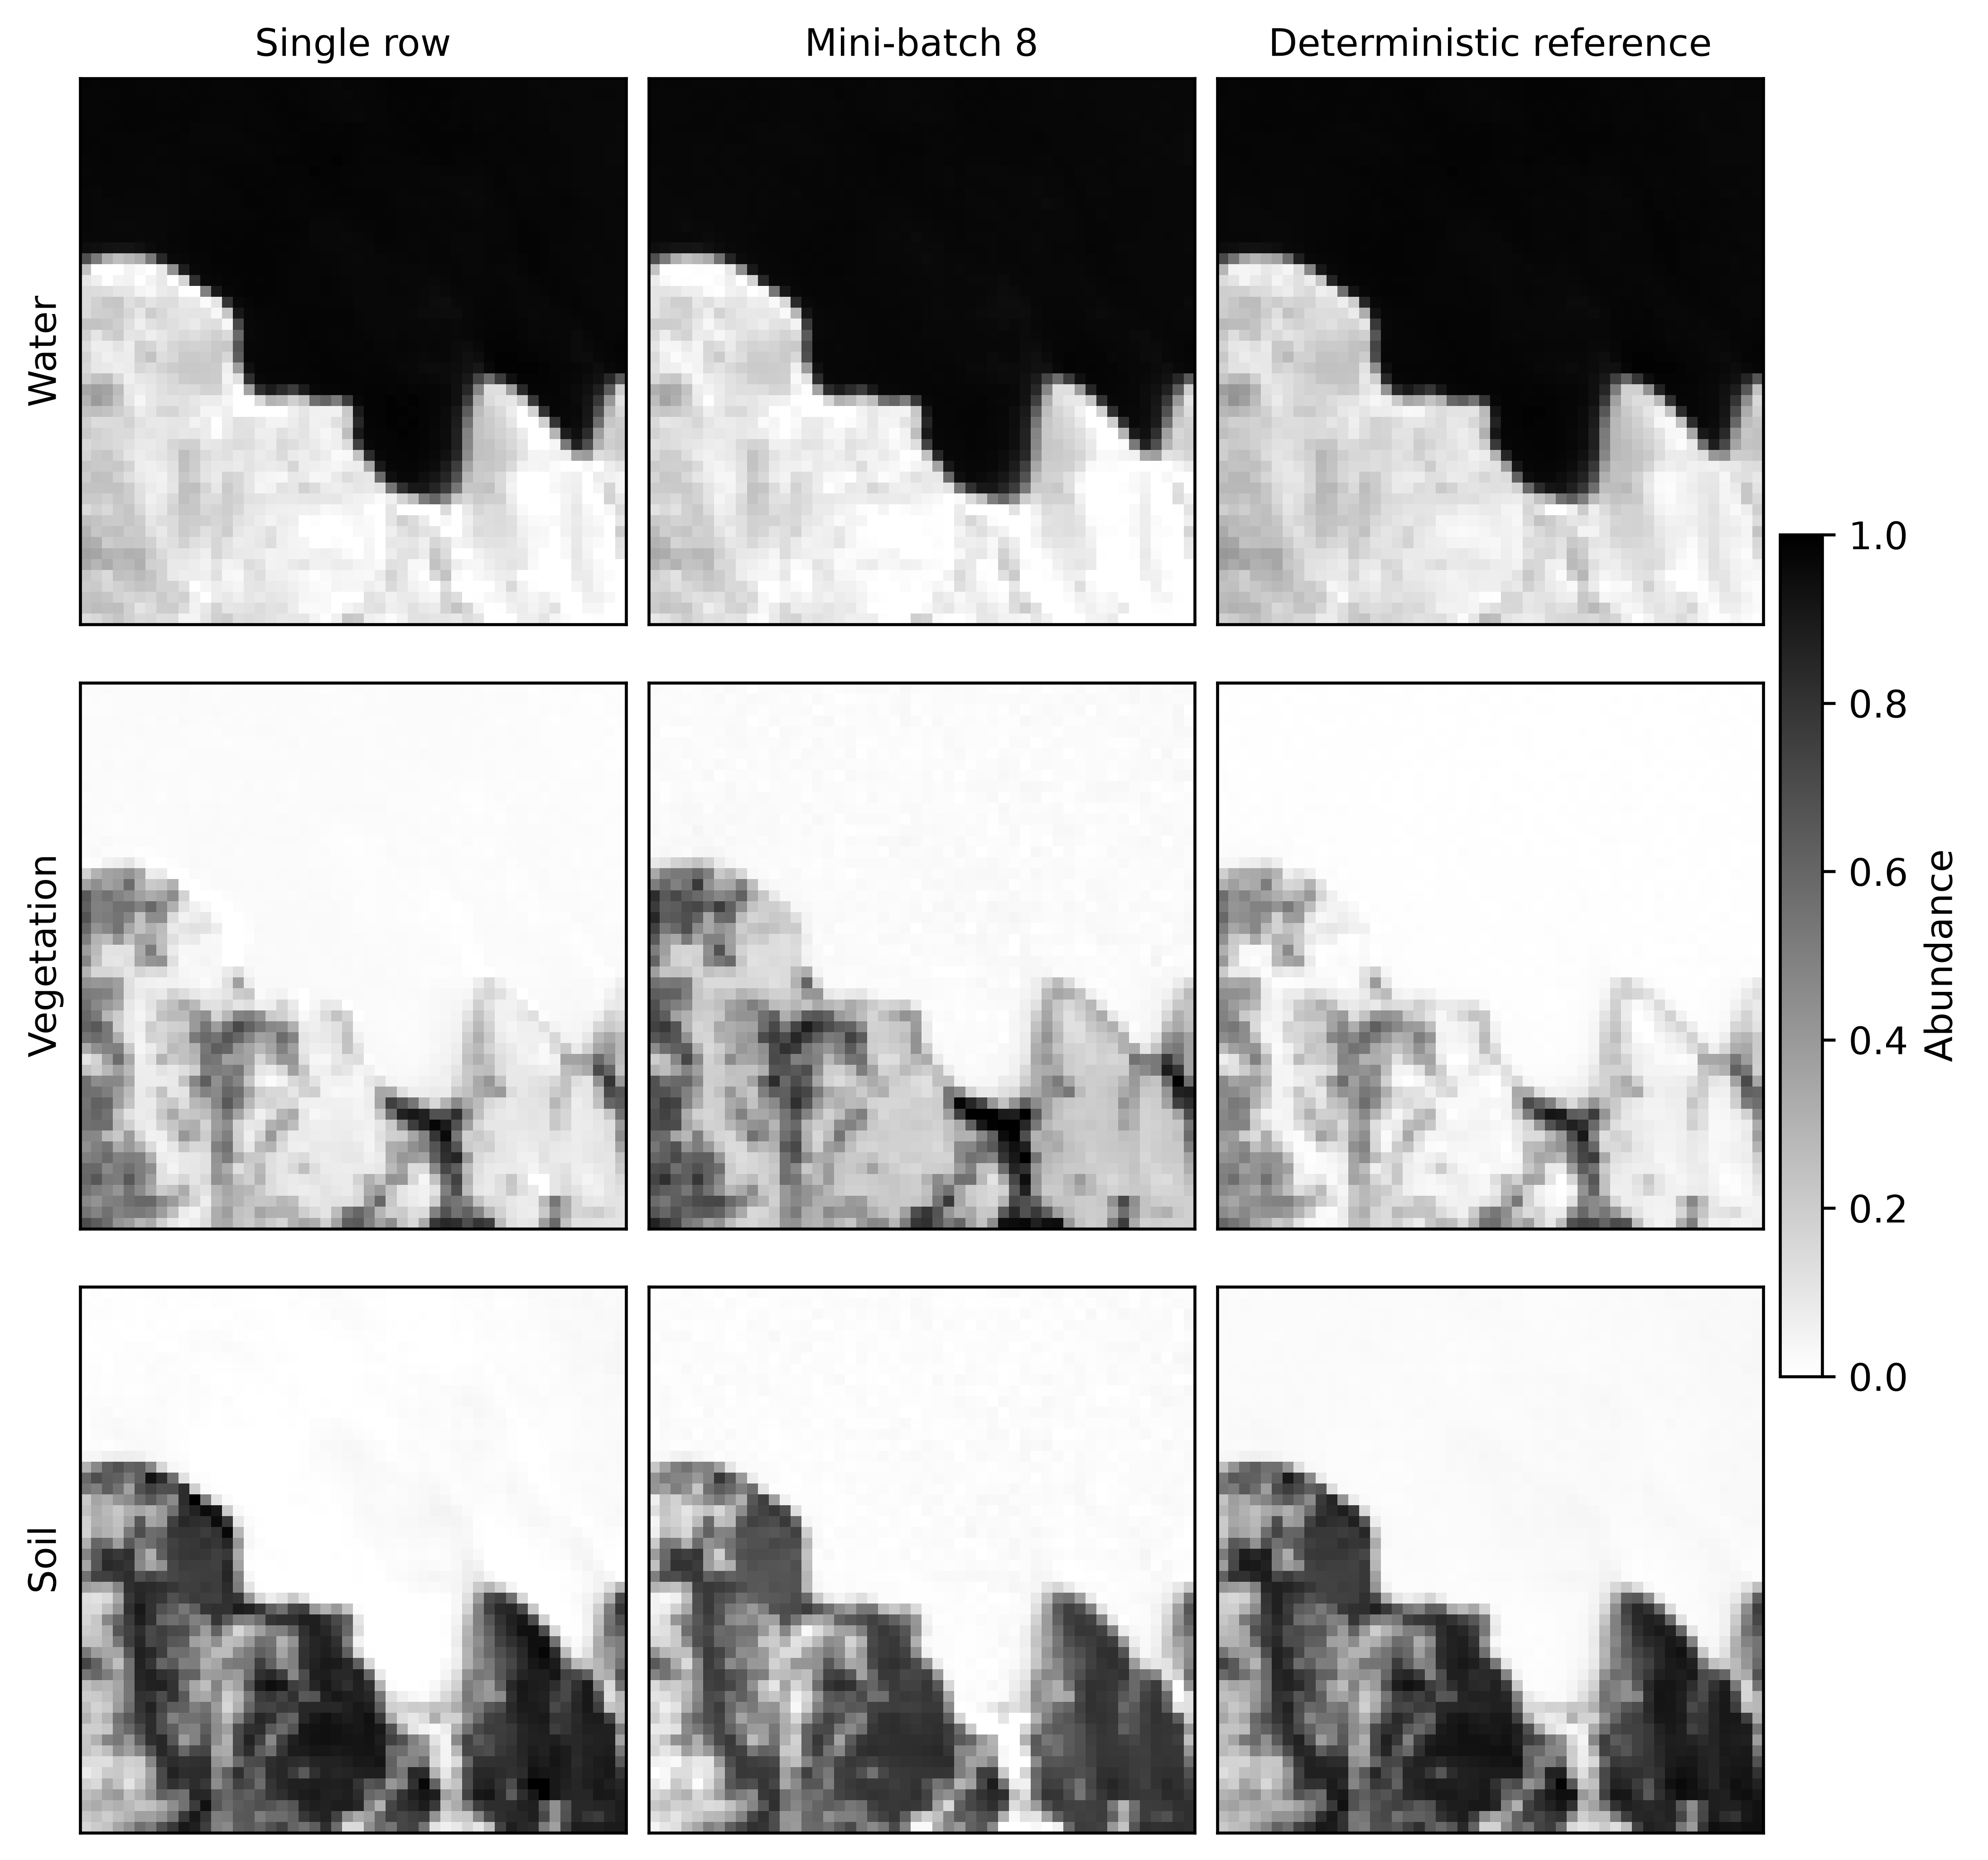

In [8]:
display(Image(filename=str(OUTPUT_DIR / "fig_moffett_abundance_comparison_r3.png")))

## 11. Spectral-Signature Figure

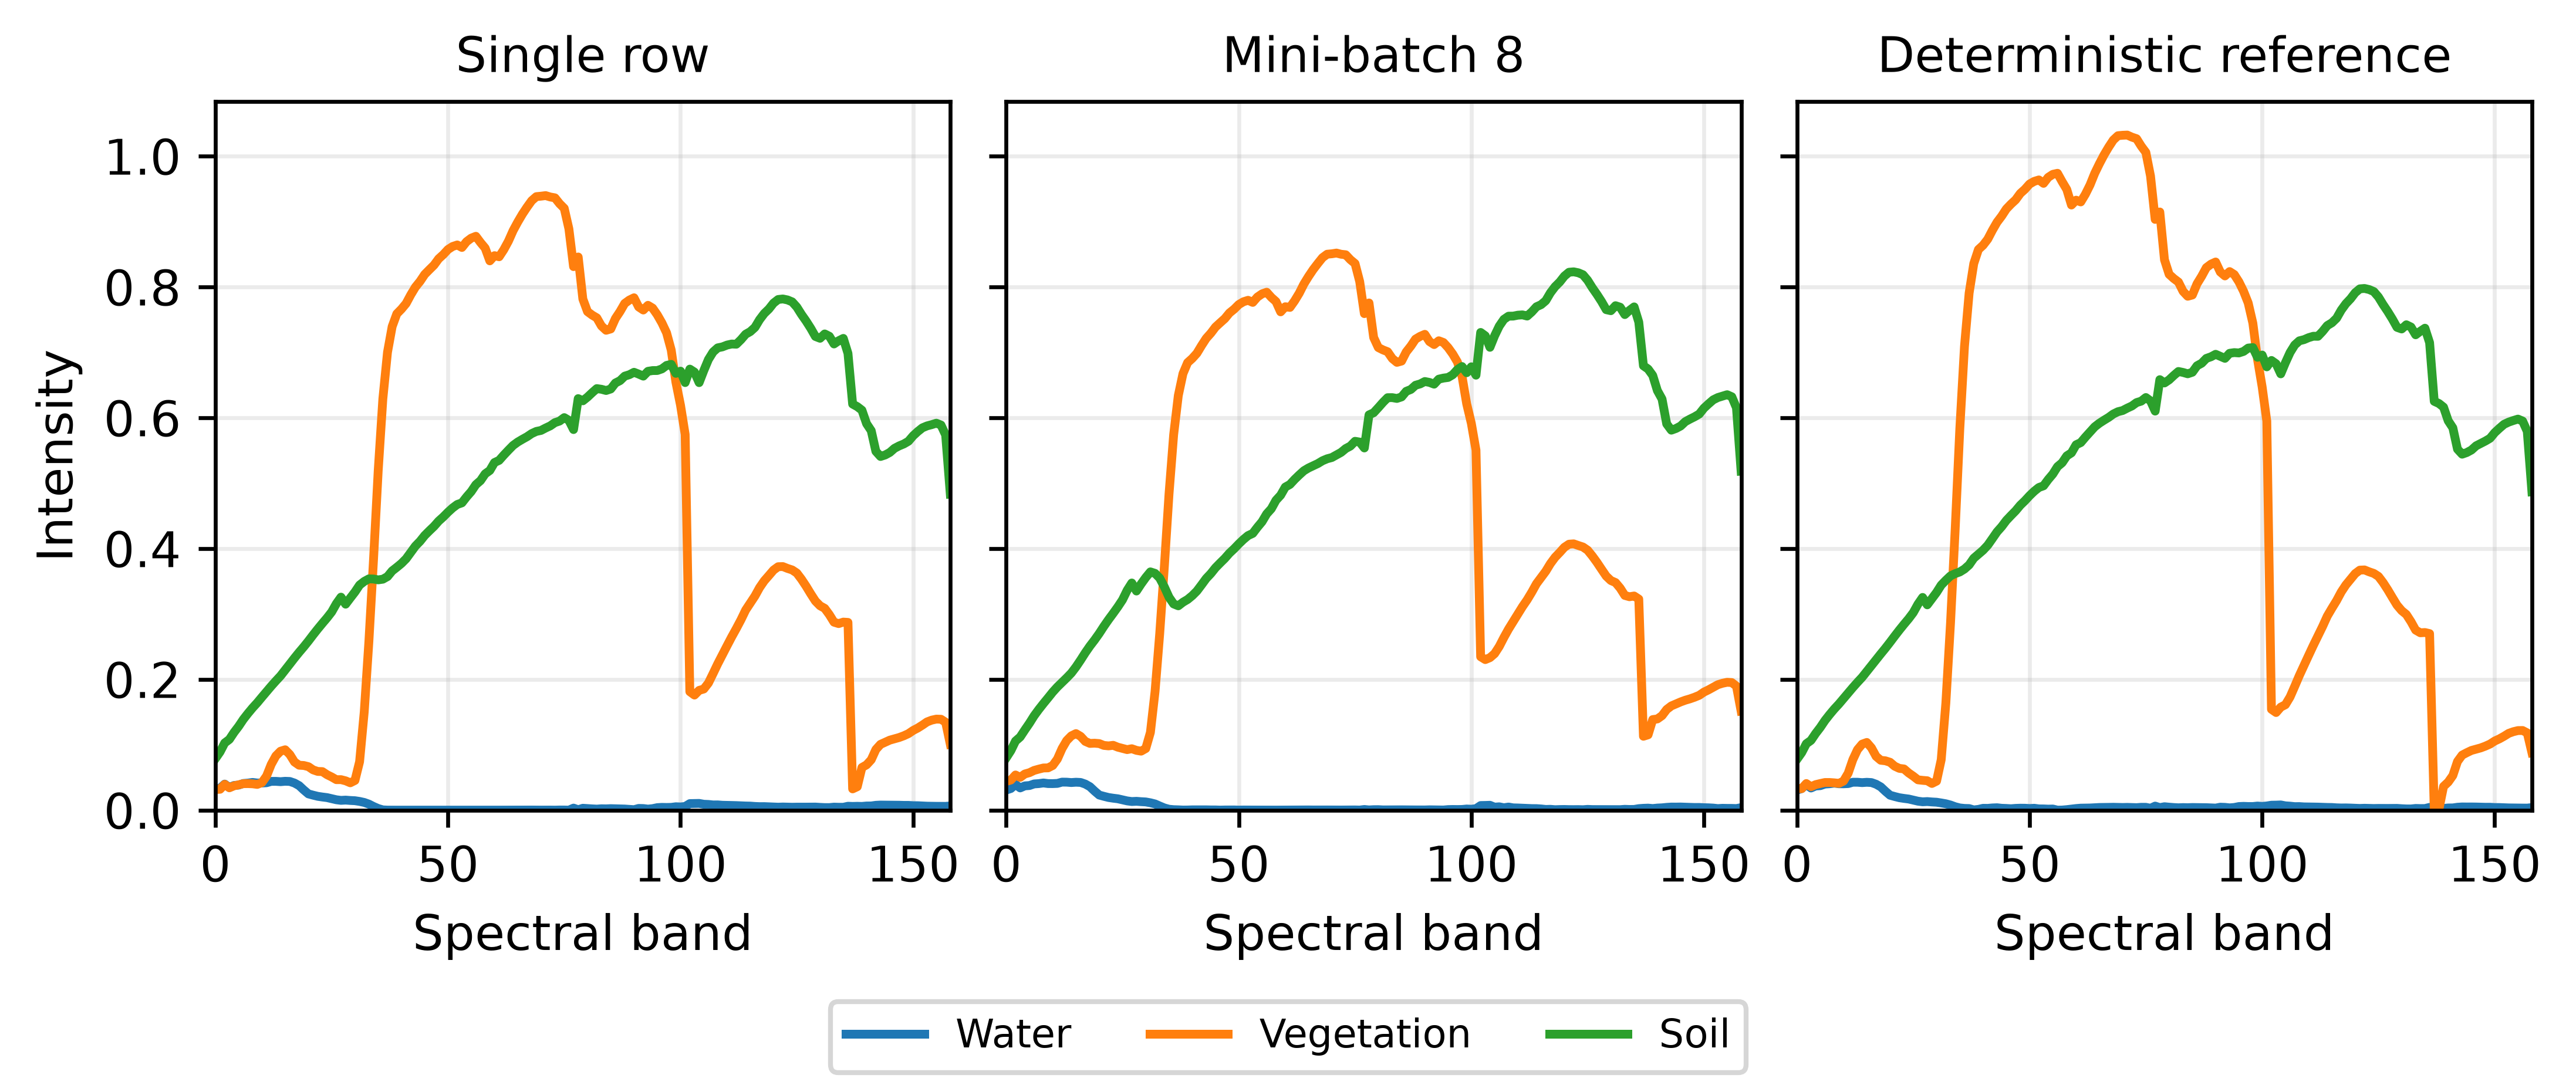

In [9]:
display(Image(filename=str(OUTPUT_DIR / "fig_moffett_spectral_comparison_r3.png")))

## 12. Convergence Figure

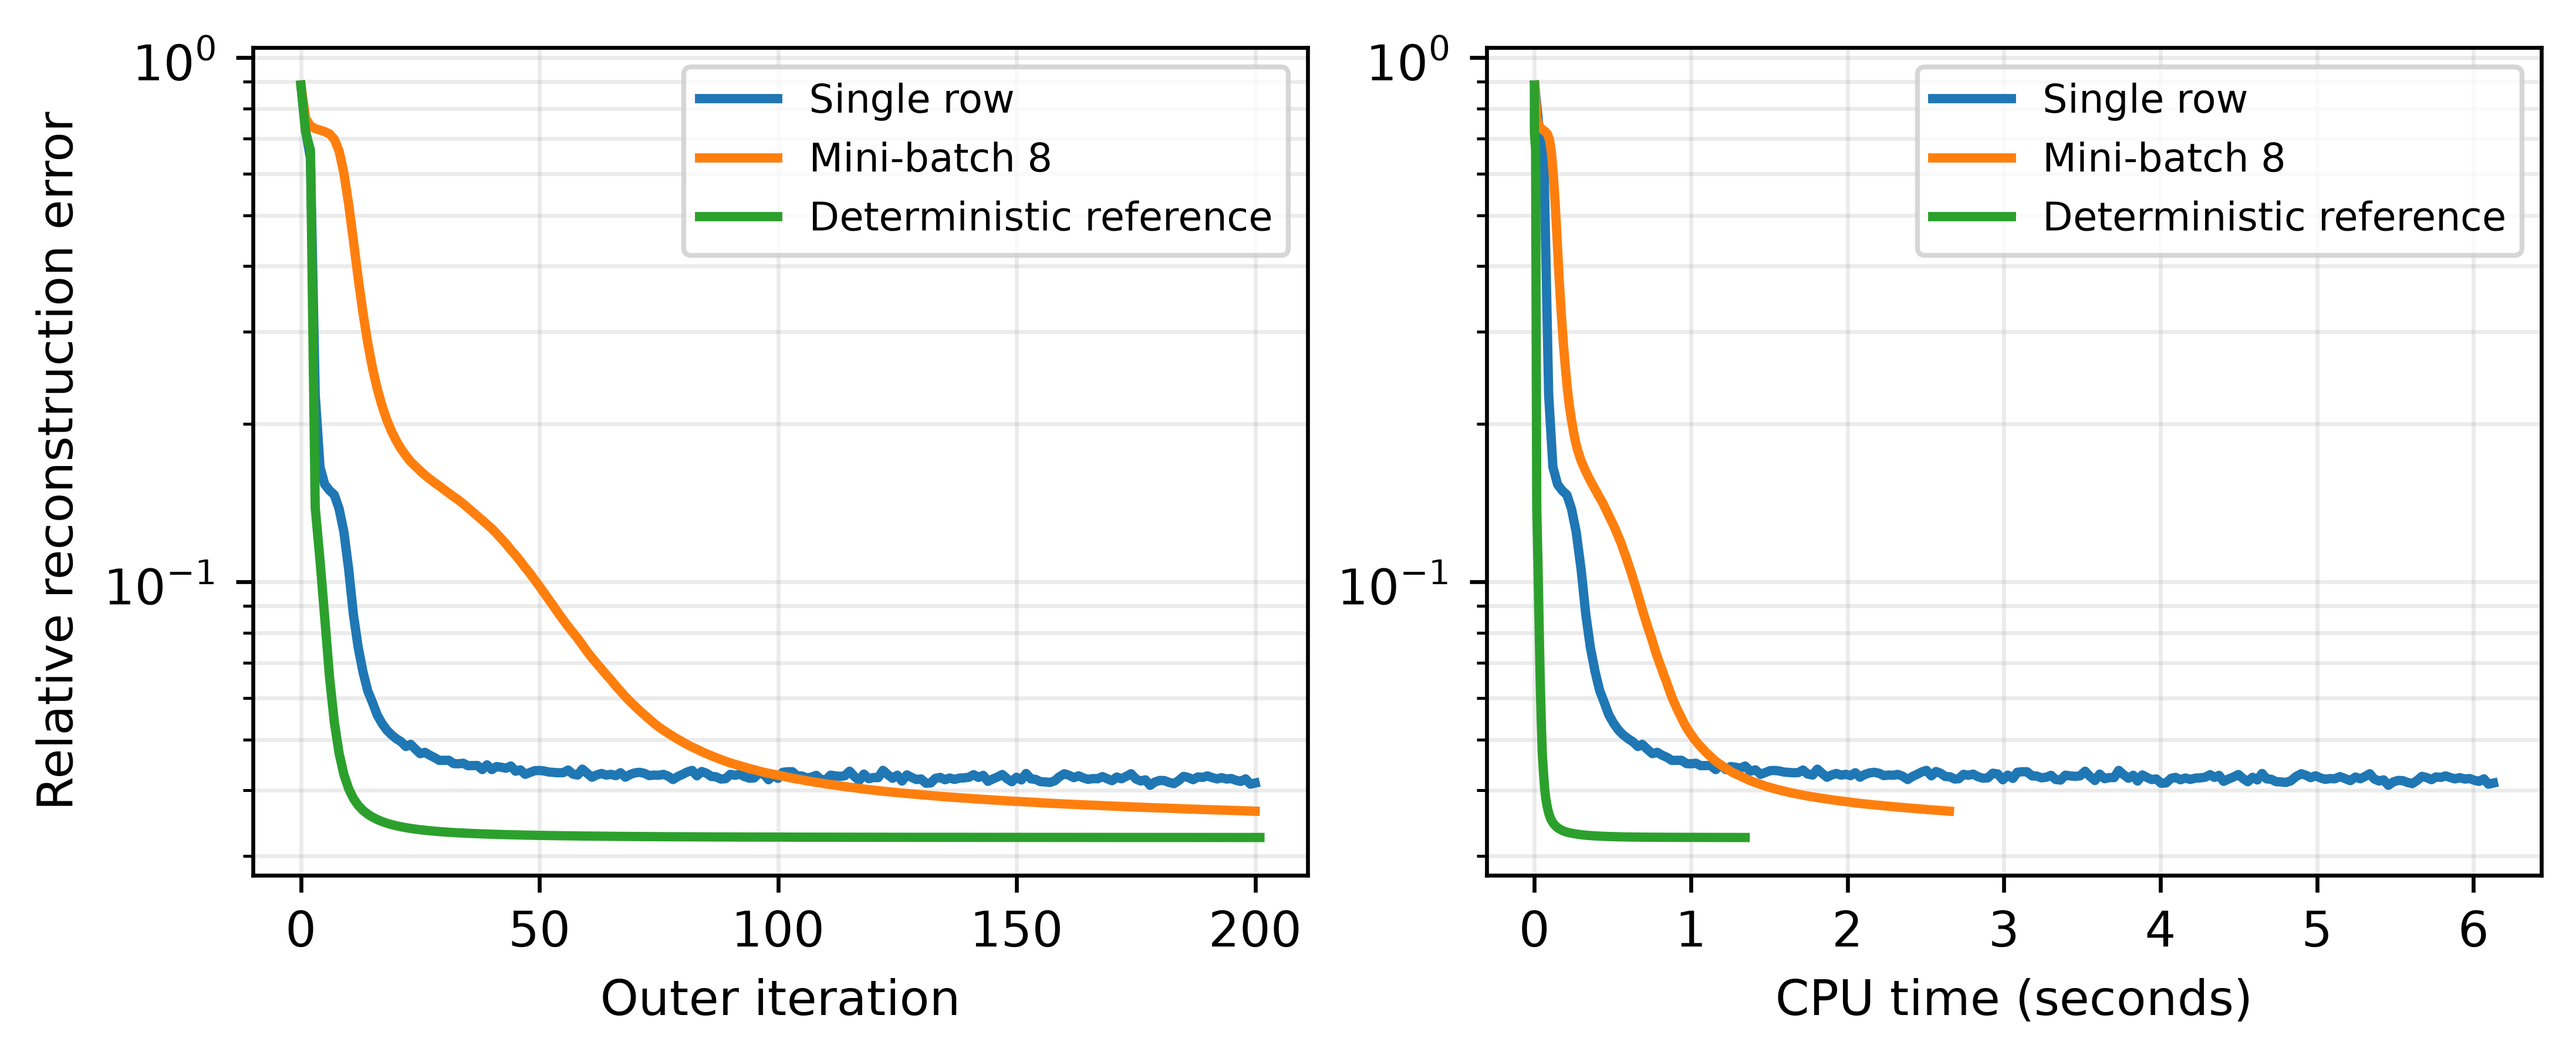

In [10]:
display(Image(filename=str(OUTPUT_DIR / "fig_moffett_convergence_comparison_r3.png")))

## 13. Constraint Checks

In [11]:
checks = []
for method in comparison.METHODS:
    factors = np.load(OUTPUT_DIR / f"factors_{method}_seed{SEED}.npz")
    W = factors["W_final"]
    H = factors["H_final"]
    simplex_sum, h_neg = comparison.simplex_violation(H)
    checks.append({
        "method": method,
        "simplex_violation": simplex_sum,
        "H_negativity": h_neg,
        "W_negativity": comparison.nonnegativity_violation(W),
        "finite_W": np.isfinite(W).all(),
        "finite_H": np.isfinite(H).all(),
    })
display(Markdown(markdown_table(checks)))

| method | simplex_violation | H_negativity | W_negativity | finite_W | finite_H |
|---|---|---|---|---|---|
| single_row_fixed | 2.220446049250313e-16 | 0.0 | 0.0 | True | True |
| minibatch8_fixed | 2.220446049250313e-16 | 0.0 | 0.0 | True | True |
| reference | 2.220446049250313e-16 | 0.0 | 0.0 | True | True |

## 14. Exact List of Generated Files

In [12]:
generated = sorted([str(path) for path in OUTPUT_DIR.rglob("*") if path.is_file()])
generated += sorted([str(path) for path in FIGURE_DIR.rglob("*") if path.is_file()])
for item in generated:
    print(item)

../results/04_simplex_nmf_comparison/common_config_seed123.json
../results/04_simplex_nmf_comparison/component_alignment_seed123.json
../results/04_simplex_nmf_comparison/config_minibatch8_fixed_seed123.json
../results/04_simplex_nmf_comparison/config_reference_seed123.json
../results/04_simplex_nmf_comparison/config_single_row_fixed_seed123.json
../results/04_simplex_nmf_comparison/factors_minibatch8_fixed_seed123.npz
../results/04_simplex_nmf_comparison/factors_reference_seed123.npz
../results/04_simplex_nmf_comparison/factors_single_row_fixed_seed123.npz
../results/04_simplex_nmf_comparison/fig_moffett_abundance_comparison_r3.png
../results/04_simplex_nmf_comparison/fig_moffett_convergence_comparison_r3.png
../results/04_simplex_nmf_comparison/fig_moffett_spectral_comparison_r3.png
../results/04_simplex_nmf_comparison/history_minibatch8_fixed_seed123.npz
../results/04_simplex_nmf_comparison/history_reference_seed123.npz
../results/04_simplex_nmf_comparison/history_single_row_fixed_s